# Food Safety Detection: MiniLM + DeBERTa Pipeline

Detects food safety complaints in Amazon reviews using a simple two-stage NLP pipeline.  
**No keyword lists, no regex** — purely semantic similarity.

| Stage | Model | Job |
|-------|-------|-----|
| 1 | `all-MiniLM-L6-v2` | Cast a wide net — find reviews semantically similar to known safety complaints |
| 2 | `cross-encoder/nli-deberta-v3-small` | Precision filter — remove false positives from Stage 1 |

**Post-processing:** Late weighting penalises 4–5★ reviews to further suppress false positives.

---
## 1. Setup

In [108]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient, UpdateOne
from tqdm import tqdm
import torch

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [109]:
# Connect to MongoDB
# Make sure mongod is running before executing this cell
CLIENT = MongoClient('mongodb://localhost:27017/')
DB     = CLIENT['amazon_reviews']
COL    = DB['reviews']

print('Connected to MongoDB.')
print(f'Documents in collection: {COL.count_documents({}):,}')

Connected to MongoDB.
Documents in collection: 568,454


In [110]:
# Load the CSV into MongoDB — skipped automatically if collection already has data
CSV_PATH = 'Reviews_withURL.csv'

if COL.count_documents({}) == 0:
    print('Importing CSV...')
    df_import = pd.read_csv(CSV_PATH, index_col=0)
    df_import = df_import.dropna(subset=['Text', 'Score'])

    for col in ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']:
        df_import[col] = pd.to_numeric(df_import[col], errors='coerce')
    df_import = df_import.dropna(subset=['Id'])

    records = df_import.to_dict(orient='records')
    BATCH   = 10_000
    for i in range(0, len(records), BATCH):
        COL.insert_many(records[i:i+BATCH])
        print(f'  Inserted {min(i+BATCH, len(records)):,}/{len(records):,}', end='\r')

    print(f'\nDone. Total: {COL.count_documents({}):,}')
else:
    print(f'Collection already has {COL.count_documents({}):,} documents. Skipping.')

Collection already has 568,454 documents. Skipping.


---
## 2. Stage 1 — MiniLM Semantic Search

MiniLM converts each review into a vector and measures how similar it is to a set of **safety probe sentences**.  
Reviews above the similarity threshold are passed to Stage 2.

**Why deduplicate?**  
Amazon reviews can appear under multiple products (same text, different `ProductId`).  
We encode each unique text **once** and fan the score out to all matching documents — ~30% fewer GPU passes.

In [111]:
import pickle
from sentence_transformers import SentenceTransformer, util

# ── Cache settings ────────────────────────────────────────────────────
# Results are saved here after the first run.
# Delete the file to force a full re-run, otherwise the cached version is used.
CACHE_DIR     = 'cache'
CACHE_MINILM  = os.path.join(CACHE_DIR, 'stage1_minilm.pkl')   # MiniLM Stage 1 results
CACHE_DEBERTA = os.path.join(CACHE_DIR, 'stage2_deberta.pkl')  # DeBERTa Stage 2 results
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'Cache folder : {os.path.abspath(CACHE_DIR)}')
print(f'  stage1_minilm.pkl  : {"EXISTS — will skip MiniLM encoding" if os.path.exists(CACHE_MINILM)  else "not found — will run MiniLM"}')
print(f'  stage2_deberta.pkl : {"EXISTS — will skip DeBERTa inference" if os.path.exists(CACHE_DEBERTA) else "not found — will run DeBERTa"}')

# ── Settings ─────────────────────────────────────────────────────────
SEMANTIC_THRESHOLD = 0.39
ENCODE_BATCH_SIZE  = 256
MAX_CHARS          = 384

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Only load the model if we actually need to run encoding
if os.path.exists(CACHE_MINILM):
    print(f'\nMiniLM model load skipped (cache exists).')
    model            = None
    probe_embeddings = None
else:
    print(f'\nLoading MiniLM on {device.upper()}...')
    model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

    SAFETY_PROBES = [
        # Illness
        'Contracted severe food poisoning and vomiting',
        'Diagnosed with salmonella gastroenteritis infection',
        'Intense nausea and violent diarrhea all night',
        # Contamination
        'Disgusting maggots and worms crawling inside',
        'Sharp glass shards and hard plastic pieces hidden',
        'Tasted like toxic chemical bleach and soap',
        # Spoilage
        'Smells completely rancid, rotten, and putrid',
        'Covered in fuzzy green mold and fungus',
        'The can was bulging, bloated, and leaking',
        # Allergen
        'Anaphylactic shock, throat swelling, and breathing difficulty',
        'Severe allergic reaction and skin hives breakout',
        'Dangerous undisclosed hidden allergens ingredients',
        # Quality defect
        'Chipped my tooth on a hard dangerous object',
        'Tampered broken safety seal risk',
    ]
    probe_embeddings = model.encode(SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False)
    print(f'Model ready. {len(SAFETY_PROBES)} safety probes encoded.')

print(f'Similarity threshold: {SEMANTIC_THRESHOLD}')

Cache folder : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\cache
  stage1_minilm.pkl  : EXISTS — will skip MiniLM encoding
  stage2_deberta.pkl : EXISTS — will skip DeBERTa inference

MiniLM model load skipped (cache exists).
Similarity threshold: 0.39


In [112]:
from collections import defaultdict

# Build a map: unique text → list of MongoDB _ids that share that exact text.
# This way we encode each unique review only once.
print('Building deduplication map...')
text_to_ids = defaultdict(list)

for doc in COL.find({'Text': {'$exists': True, '$ne': ''}}, {'_id': 1, 'Text': 1}):
    text_to_ids[str(doc['Text'])].append(doc['_id'])

unique_texts = list(text_to_ids.keys())
total_docs   = sum(len(v) for v in text_to_ids.values())

print(f'Total documents : {total_docs:,}')
print(f'Unique texts    : {len(unique_texts):,}')
print(f'Duplicates skip : {total_docs - len(unique_texts):,}  (no re-encoding needed)')

Building deduplication map...
Total documents : 568,454
Unique texts    : 393,579
Duplicates skip : 174,875  (no re-encoding needed)


In [113]:
if os.path.exists(CACHE_MINILM):
    print(f'Cache found: {CACHE_MINILM}')
    print('Skipping MiniLM encoding. Delete the file to re-run.')
else:
    # Encode every unique text and write the similarity score back to MongoDB.
    # Each score is fanned out to all _ids that share the same text.
    COL.create_index([('SemanticScore', 1)], sparse=True, background=True)

    batch_texts = []
    batch_keys  = []

    with tqdm(total=len(unique_texts), desc='MiniLM encoding', unit='texts') as pbar:
        for text in unique_texts:
            batch_texts.append(text[:MAX_CHARS])
            batch_keys.append(text)

            if len(batch_texts) == ENCODE_BATCH_SIZE:
                embeddings = model.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
                scores     = util.cos_sim(embeddings, probe_embeddings).max(dim=1).values.cpu().numpy()

                ops = []
                for key, score in zip(batch_keys, scores):
                    for doc_id in text_to_ids[key]:
                        ops.append(UpdateOne(
                            {'_id': doc_id},
                            {'$set': {
                                'SemanticScore':   float(score),
                                'SemanticFlagged': float(score) >= SEMANTIC_THRESHOLD,
                            }}
                        ))
                COL.bulk_write(ops, ordered=False)

                batch_texts = []
                batch_keys  = []
                pbar.update(ENCODE_BATCH_SIZE)

        # Flush the last partial batch
        if batch_texts:
            embeddings = model.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
            scores     = util.cos_sim(embeddings, probe_embeddings).max(dim=1).values.cpu().numpy()
            ops = []
            for key, score in zip(batch_keys, scores):
                for doc_id in text_to_ids[key]:
                    ops.append(UpdateOne(
                        {'_id': doc_id},
                        {'$set': {
                            'SemanticScore':   float(score),
                            'SemanticFlagged': float(score) >= SEMANTIC_THRESHOLD,
                        }}
                    ))
            COL.bulk_write(ops, ordered=False)
            pbar.update(len(batch_texts))

    print('Encoding complete. Scores saved to MongoDB.')

Cache found: cache\stage1_minilm.pkl
Skipping MiniLM encoding. Delete the file to re-run.


In [114]:
if os.path.exists(CACHE_MINILM):
    print(f'Loading Stage 1 results from cache: {CACHE_MINILM}')
    with open(CACHE_MINILM, 'rb') as f:
        df = pickle.load(f)
    print(f'Loaded {len(df):,} rows from cache.')
else:
    print('Loading Stage 1 results from MongoDB...')
    cursor = COL.find(
        {'SemanticScore': {'$exists': True}},
        {'_id': 1, 'Score': 1, 'SemanticScore': 1, 'SemanticFlagged': 1}
    )
    df = pd.DataFrame(list(cursor))
    df['SemanticFlagged'] = df['SemanticFlagged'].fillna(False).astype(bool)

    print(f'Saving Stage 1 cache...')
    with open(CACHE_MINILM, 'wb') as f:
        pickle.dump(df, f)
    print(f'Cache saved: {CACHE_MINILM}')

df['SemanticFlagged'] = df['SemanticFlagged'].fillna(False).astype(bool)
total   = len(df)
flagged = int(df['SemanticFlagged'].sum())

print(f'\nTotal reviews  : {total:,}')
print(f'MiniLM flagged : {flagged:,}  ({flagged / total:.2%})')
print(f'Not flagged    : {total - flagged:,}')
print('\nStage 1 done. Proceed to DeBERTa.')

Loading Stage 1 results from cache: cache\stage1_minilm.pkl
Loaded 568,454 rows from cache.

Total reviews  : 568,454
MiniLM flagged : 23,587  (4.15%)
Not flagged    : 544,867

Stage 1 done. Proceed to DeBERTa.


---
## 3. Stage 2 — DeBERTa Precision Filter

MiniLM casts a wide net — some false positives slip through (e.g. *"This tea cured my nausea!"*).  
DeBERTa re-reads only the MiniLM candidates (~3–10% of the dataset) and classifies them into one of six labels.
Reviews classified as **`Safe`** are discarded (score set to 0.0).

| Label | Meaning |
|-------|---------|
| `Safe` | Customer used health language positively — not a hazard |
| `Illness` | Food poisoning, nausea, vomiting, infection |
| `Contamination` | Mold, insects, foreign objects |
| `Spoilage` | Expired, rotten, rancid |
| `Allergen` | Allergic reaction, undisclosed allergens |
| `Quality_Defect` | Broken packaging, undercooked food |

In [115]:
from transformers import pipeline as hf_pipeline

# ── These label definitions are always needed (cache or not) ──────────
SAFETY_LABELS = [
    'is safe and helped the consumer recover from previous health issues',
    'caused severe illness, food poisoning, or sickness',
    'contained physical contamination, mold, insects, or foreign objects',
    'was spoiled, expired, rotten, or smelled bad',
    'triggered a severe allergic reaction or contained undisclosed allergens',
    'had packaging defects, broken glass, or undercooked food',
]

LABEL_TO_CATEGORY = {
    'is safe and helped the consumer recover from previous health issues': 'Safe',
    'caused severe illness, food poisoning, or sickness':                  'Illness',
    'contained physical contamination, mold, insects, or foreign objects': 'Contamination',
    'was spoiled, expired, rotten, or smelled bad':                        'Spoilage',
    'triggered a severe allergic reaction or contained undisclosed allergens': 'Allergen',
    'had packaging defects, broken glass, or undercooked food':            'Quality_Defect',
}

SEVERITY_MAP = {
    'Illness':        'High',
    'Contamination':  'High',
    'Allergen':       'High',
    'Spoilage':       'Medium',
    'Quality_Defect': 'Low',
}

if os.path.exists(CACHE_DEBERTA):
    print(f'DeBERTa cache found: {CACHE_DEBERTA}')
    print('Loading candidates from cache — model will not be loaded.')
    with open(CACHE_DEBERTA, 'rb') as f:
        candidates = pickle.load(f)
    print(f'Loaded {len(candidates):,} candidates from cache.')
    deberta = None  # not needed
else:
    # ── Get MiniLM candidates and fetch their text from MongoDB ──────
    candidates = df[df['SemanticFlagged']].copy().reset_index(drop=True)

    print(f'Fetching text for {len(candidates):,} candidates from MongoDB...')
    cand_ids = candidates['_id'].tolist()
    text_map = {d['_id']: d.get('Text', '') for d in COL.find({'_id': {'$in': cand_ids}}, {'Text': 1})}
    candidates['Text'] = candidates['_id'].map(text_map).fillna('')
    print(f'Text loaded for {candidates["Text"].ne("").sum():,} candidates.\n')

    # ── Load DeBERTa model ────────────────────────────────────────────
    device_id = 0 if torch.cuda.is_available() else -1
    print('Loading DeBERTa model (cross-encoder/nli-deberta-v3-small)...')
    deberta = hf_pipeline(
        'zero-shot-classification',
        model='cross-encoder/nli-deberta-v3-small',
        device=device_id,
    )
    print(f'Model ready. Will run on {len(candidates):,} candidates.')

DeBERTa cache found: cache\stage2_deberta.pkl
Loading candidates from cache — model will not be loaded.
Loaded 23,587 candidates from cache.


In [116]:
DEBERTA_THRESHOLD = 0.50
MAX_CHARS_DEB     = 256
DEBERTA_BATCH     = 16

if os.path.exists(CACHE_DEBERTA):
    print(f'Using cached DeBERTa results. Skipping inference.')
else:
    texts      = candidates['Text'].str[:MAX_CHARS_DEB].tolist()
    scores_out = []
    cats_out   = []
    sevs_out   = []

    for i in tqdm(range(0, len(texts), DEBERTA_BATCH), desc='DeBERTa inference'):
        batch   = texts[i:i+DEBERTA_BATCH]
        results = deberta(
            batch,
            candidate_labels=SAFETY_LABELS,
            hypothesis_template='This review describes a product that {}.'
        )
        for res in results:
            top_label = res['labels'][0]
            top_score = res['scores'][0]
            category  = LABEL_TO_CATEGORY[top_label]

            if category == 'Safe':
                scores_out.append(0.0)
                cats_out.append('Safe')
                sevs_out.append('None')
            else:
                scores_out.append(top_score)
                cats_out.append(category)
                sevs_out.append(SEVERITY_MAP.get(category, 'Unknown'))

    candidates['DebertaScore']     = scores_out
    candidates['Category']         = cats_out
    candidates['Severity']         = sevs_out
    candidates['DebertaConfirmed'] = candidates['DebertaScore'] >= DEBERTA_THRESHOLD

    # Save cache so the next run can skip inference entirely
    print(f'Saving DeBERTa cache...')
    with open(CACHE_DEBERTA, 'wb') as f:
        pickle.dump(candidates, f)
    print(f'Cache saved: {CACHE_DEBERTA}')

confirmed = candidates[candidates['DebertaConfirmed']].copy()
false_pos = len(candidates) - len(confirmed)

print(f'\nStage 1  (MiniLM  >= {SEMANTIC_THRESHOLD}) : {len(candidates):,}')
print(f'Stage 2  (DeBERTa >= {DEBERTA_THRESHOLD}) : {len(confirmed):,}')
print(f'False positives removed          : {false_pos:,}  ({false_pos / max(len(candidates), 1):.1%})')

Using cached DeBERTa results. Skipping inference.

Stage 1  (MiniLM  >= 0.39) : 23,587
Stage 2  (DeBERTa >= 0.5) : 4,878
False positives removed          : 18,709  (79.3%)


---
## 4. Late Weighting

DeBERTa detects hazard language but cannot determine *direction* —  
a 5-star review saying *"cured my nausea"* scores similarly to a 1-star *"caused nausea"*.

Fix: multiply the DeBERTa score by a penalty based on the star rating **after** inference.

| Stars | Weight | Reason |
|:-----:|:------:|--------|
| 1–2 | 1.0 | Genuine complaint — keep raw score |
| 3   | 0.8 | Neutral — slight downward adjustment |
| 4–5 | 0.1 | Heavy penalty — satisfied customers are not safety victims |

In [117]:
def get_weight(star_rating):
    if star_rating in (1, 2):
        return 1.0
    elif star_rating == 3:
        return 0.8
    else:            # 4 or 5 stars
        return 0.1

confirmed = confirmed.copy()
confirmed['Weight']           = confirmed['Score'].apply(get_weight)
confirmed['FinalSafetyScore'] = (confirmed['DebertaScore'] * confirmed['Weight']).round(4)

print('=== FinalSafetyScore After Weighting ===')
print(confirmed['FinalSafetyScore'].describe().round(4).to_string())

before = int((confirmed['DebertaScore']     >= 0.85).sum())
after  = int((confirmed['FinalSafetyScore'] >= 0.85).sum())
print(f'\nDebertaScore     >= 0.85 : {before:,}')
print(f'FinalSafetyScore >= 0.85 : {after:,}')
print(f'Suppressed by weighting  : {before - after:,}')


=== FinalSafetyScore After Weighting ===
count    4878.0000
mean        0.4327
std         0.3099
min         0.0500
25%         0.0674
50%         0.5240
75%         0.6662
max         0.9973

DebertaScore     >= 0.85 : 694
FinalSafetyScore >= 0.85 : 444
Suppressed by weighting  : 250


---
## 5. Results & Export

In [118]:
n_total     = len(df)
n_minilm    = int(df['SemanticFlagged'].sum())
n_confirmed = len(confirmed)

print('=== Two-Stage Pipeline — Final Summary ===')
print(f'  Total reviews analysed     : {n_total:,}')
print(f'  Stage 1  MiniLM flagged    : {n_minilm:,}  ({n_minilm / n_total:.2%})')
print(f'  Stage 2  DeBERTa confirmed : {n_confirmed:,}  ({n_confirmed / n_total:.2%})')

print('\n=== Confirmed Reviews by Category ===')
print(confirmed[confirmed['Category'] != 'Safe']['Category'].value_counts().to_string())

print('\n=== Top 5 Highest-Risk Reviews ===')
top5 = confirmed.sort_values('FinalSafetyScore', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Score']}* | {row['Category']} | DeBERTa: {row['DebertaScore']:.3f} | Weight: {row['Weight']} | Final: {row['FinalSafetyScore']:.3f}")
    print(f"  {str(row['Text'])[:250]}...")
    print('  ' + '-' * 68)


=== Two-Stage Pipeline — Final Summary ===
  Total reviews analysed     : 568,454
  Stage 1  MiniLM flagged    : 23,587  (4.15%)
  Stage 2  DeBERTa confirmed : 4,878  (0.86%)

=== Confirmed Reviews by Category ===
Category
Contamination     2578
Spoilage          1060
Illness            730
Quality_Defect     329
Allergen           181

=== Top 5 Highest-Risk Reviews ===
  1* | Contamination | DeBERTa: 0.997 | Weight: 1.0 | Final: 0.997
  I was so looking forward to these mushrooms.  After I hydrated them there were dozens of little white objects, looking suspiciously like rehydrated worms, sticking out of every nook....
  --------------------------------------------------------------------
  1* | Contamination | DeBERTa: 0.990 | Weight: 1.0 | Final: 0.990
  The ingredients are:  water, fresh mushrooms, canola or soybean oil, enriched wheat flour, fresh cream, corn starch salt, whey powder, soy protein isolate, monosodium glutamate, tomato paste, calcium caseinate(a milk protein), spic

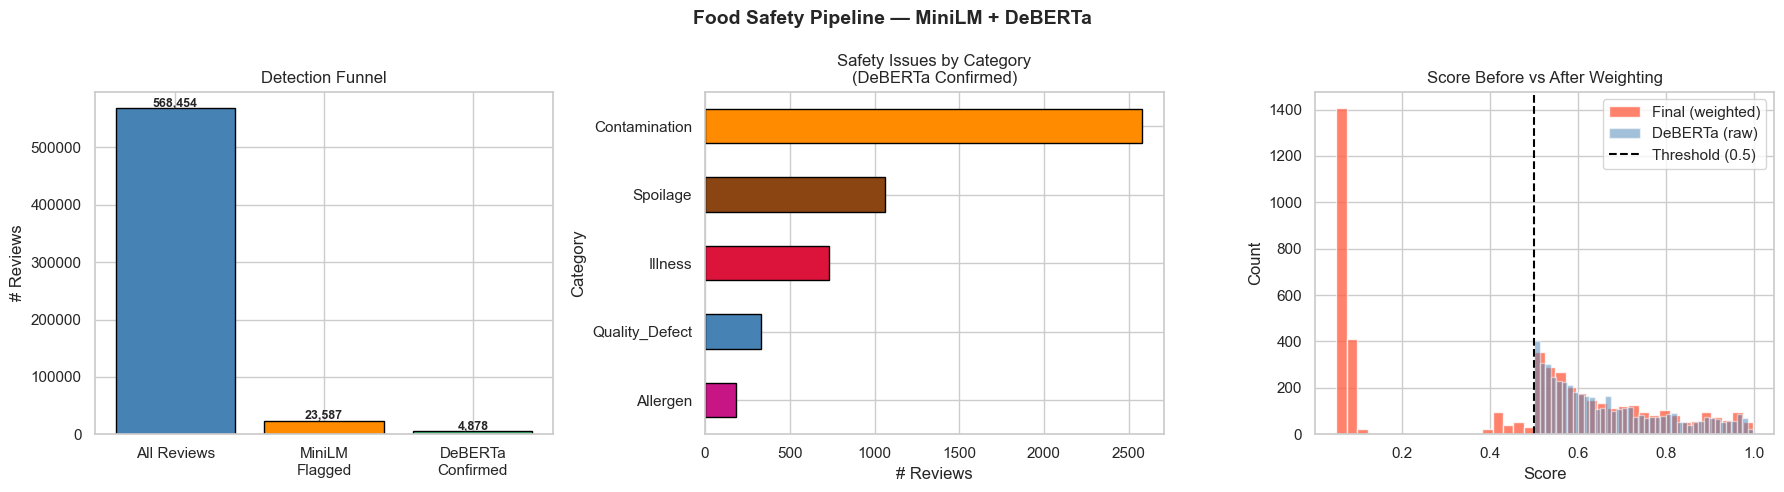

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Food Safety Pipeline — MiniLM + DeBERTa', fontsize=14, fontweight='bold')

# Panel 1: Pipeline funnel
stage_labels = ['All Reviews', 'MiniLM\nFlagged', 'DeBERTa\nConfirmed']
stage_counts = [n_total, n_minilm, n_confirmed]
bar_colors   = ['steelblue', 'darkorange', 'mediumseagreen']
bars = axes[0].bar(stage_labels, stage_counts, color=bar_colors, edgecolor='black')
axes[0].set_title('Detection Funnel')
axes[0].set_ylabel('# Reviews')
for bar, val in zip(bars, stage_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + n_total * 0.005,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Category breakdown
cat_counts   = confirmed[confirmed['Category'] != 'Safe']['Category'].value_counts()
cat_colors   = {
    'Illness': 'crimson', 'Contamination': 'darkorange',
    'Allergen': 'mediumvioletred', 'Spoilage': 'saddlebrown', 'Quality_Defect': 'steelblue',
}
cat_counts.plot(kind='barh', ax=axes[1],
                color=[cat_colors.get(c, 'gray') for c in cat_counts.index], edgecolor='black')
axes[1].set_title('Safety Issues by Category\n(DeBERTa Confirmed)')
axes[1].set_xlabel('# Reviews')
axes[1].invert_yaxis()

# Panel 3: FinalSafetyScore distribution (after weighting)
axes[2].hist(confirmed['FinalSafetyScore'], bins=40, color='tomato', alpha=0.8, label='Final (weighted)')
axes[2].hist(confirmed['DebertaScore'],     bins=40, color='steelblue', alpha=0.5, label='DeBERTa (raw)')
axes[2].axvline(DEBERTA_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold ({DEBERTA_THRESHOLD})')
axes[2].set_title('Score Before vs After Weighting')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()


In [120]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUT_FILE = os.path.join(OUTPUT_DIR, 'food_safety_results.xlsx')

def clean_for_excel(series):
    illegal = set(chr(i) for i in list(range(0, 9)) + [11, 12] + list(range(14, 32)))
    return series.astype(str).apply(lambda s: ''.join(c for c in s if c not in illegal))

MAX_LEN = 32767

with pd.ExcelWriter(OUT_FILE, engine='openpyxl') as writer:

    # Sheet 1: All MiniLM-flagged reviews
    sheet1 = candidates[['Score', 'SemanticScore', 'Category', 'Text']].copy()
    sheet1['Text'] = clean_for_excel(sheet1['Text'].str[:MAX_LEN])
    sheet1.to_excel(writer, sheet_name='MiniLM_Flagged', index=False)

    # Sheet 2: DeBERTa-confirmed reviews with weighting scores
    export_cols = ['Score', 'SemanticScore', 'DebertaScore', 'Category', 'Severity',
                   'Weight', 'FinalSafetyScore', 'Text']
    sheet2 = confirmed[[c for c in export_cols if c in confirmed.columns]].copy()
    sheet2 = sheet2.sort_values('FinalSafetyScore', ascending=False)
    sheet2['Text'] = clean_for_excel(sheet2['Text'].str[:MAX_LEN])
    sheet2.to_excel(writer, sheet_name='DeBERTa_Confirmed', index=False)

print(f'Exported to: {os.path.abspath(OUT_FILE)}')
print(f'  Sheet "MiniLM_Flagged"    : {len(sheet1):,} rows')
print(f'  Sheet "DeBERTa_Confirmed" : {len(sheet2):,} rows')


Exported to: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\food_safety_results.xlsx
  Sheet "MiniLM_Flagged"    : 23,587 rows
  Sheet "DeBERTa_Confirmed" : 4,878 rows


---
## 6. Product-Level Safety Assessment

Group confirmed hazard reviews by `ProductId` and score each product using **Bayesian Average** smoothing.

$$\text{BayesianScore} = \frac{v \times R + m \times C}{v + m}$$

| Variable | Meaning |
|:---:|---|
| $v$ | Total reviews for this product |
| $R$ | Raw hazard score = Σ severity weights / $v$ |
| $m$ | Prior weight = Q95 of review count distribution |
| $C$ | Global mean hazard score across all products (safe products contribute 0) |

Products with few reviews are pulled toward the dataset mean $C$.
As $v$ grows, `BayesianScore` converges to the product's own raw score $R$.

| BayesianScore | Risk Level |
|:---:|:---|
| ≥ 0.30  OR  (High severity + HazardRate ≥ 10%) | 🔴 High Risk |
| ≥ 0.05 | 🟡 Medium Risk |
| < 0.05 | 🟢 Low Risk |


In [121]:
from pymongo import UpdateMany
from collections import defaultdict

confirmed = confirmed.copy()

# ── Resolve stable Amazon Id and ProductId from MongoDB ───────────────
# The Amazon integer `Id` comes from the original CSV and never changes,
# even if the MongoDB collection is dropped and reimported.
# We join on Text (also stable) because the DeBERTa cache only stores
# _id (MongoDB ObjectId), which is reassigned on every reimport.
if 'Text' not in confirmed.columns or confirmed['Text'].isna().all():
    raise RuntimeError(
        "'Text' column missing from confirmed. "
        "Delete cache/stage2_deberta.pkl and re-run Stage 2 to rebuild the cache."
    )

unique_texts = confirmed['Text'].dropna().unique().tolist()

# One query fetches Id, ProductId, and Text for all confirmed candidates.
text_to_ids_amazon: dict = defaultdict(list)   # text → [Amazon Id, ...]
text_to_products:   dict = defaultdict(list)   # text → [ProductId, ...]

for d in COL.find(
    {'Text': {'$in': unique_texts}},
    {'Text': 1, 'Id': 1, 'ProductId': 1}
):
    key  = str(d['Text'])
    prod = d.get('ProductId', 'UNKNOWN')
    aid  = d.get('Id')

    if prod not in text_to_products[key]:
        text_to_products[key].append(prod)
    if aid is not None:
        int_aid = int(aid)
        if int_aid not in text_to_ids_amazon[key]:
            text_to_ids_amazon[key].append(int_aid)

# ── Assign Amazon Id ──────────────────────────────────────────────────
# Most texts map to exactly one Amazon Id.
# For the rare case of duplicate texts with different Ids, keep the first.
confirmed['Id'] = confirmed['Text'].map(
    lambda t: text_to_ids_amazon.get(str(t), [None])[0]
)

n_id_resolved = confirmed['Id'].notna().sum()
print(f'Amazon Id resolved : {n_id_resolved:,} / {len(confirmed):,}')
if n_id_resolved < len(confirmed):
    print(f'  [WARN] {len(confirmed) - n_id_resolved:,} rows have no Amazon Id.')

# ── Assign ProductId (cycle fan-out for duplicate texts) ─────────────
text_counters: dict = defaultdict(int)

def _assign_product_id(text):
    key   = str(text) if pd.notna(text) else ''
    prods = text_to_products.get(key, ['UNKNOWN'])
    idx   = text_counters[key] % len(prods)
    text_counters[key] += 1
    return prods[idx]

confirmed['ProductId'] = confirmed['Text'].apply(_assign_product_id)

n_resolved = (confirmed['ProductId'] != 'UNKNOWN').sum()
n_unknown  = len(confirmed) - n_resolved
print(f'ProductId resolved : {n_resolved:,}')
if n_unknown:
    print(f'  [WARN] {n_unknown:,} rows have no matching ProductId (UNKNOWN).')

# ── Total reviews per product (denominator for Bayesian score) ────────
total_per_product = {
    d['_id']: d['TotalReviews']
    for d in COL.aggregate([{'$group': {'_id': '$ProductId', 'TotalReviews': {'$sum': 1}}}])
}

SEVERITY_WEIGHT = {'High': 3, 'Medium': 2, 'Low': 1, 'None': 0, 'Unknown': 0}
hazard_rows     = confirmed[confirmed['Category'] != 'Safe'].copy()

rows = []
for product_id, group in hazard_rows.groupby('ProductId'):
    total     = total_per_product.get(product_id, len(group))
    hz_count  = len(group)
    raw_score = sum(SEVERITY_WEIGHT.get(s, 0) for s in group['Severity']) / total

    rows.append({
        'ProductId':        product_id,
        'TotalReviews':     total,
        'HazardCount':      hz_count,
        'HazardRate':       round(hz_count / total, 4),
        '_raw':             round(raw_score, 6),
        'DominantCategory': group['Category'].value_counts().index[0],
        'isSafe':           False,
    })

product_summary = pd.DataFrame(rows)

# Bayesian smoothing:  BayesianScore = (v×R + m×C) / (v+m)
n_total_prods = len(total_per_product)
C = product_summary['_raw'].sum() / n_total_prods
m = float(np.percentile(list(total_per_product.values()), 95))

product_summary['BayesianScore'] = (
    (product_summary['TotalReviews'] * product_summary['_raw'] + m * C) /
    (product_summary['TotalReviews'] + m)
).round(6)

product_summary.drop(columns=['_raw'], inplace=True)

product_summary['RiskLevel'] = product_summary['BayesianScore'].apply(
    lambda s: 'High Risk' if s >= 0.20 else ('Medium Risk' if s >= 0.10 else 'Low Risk')
)

print(f'\nUnsafe products : {len(product_summary):,}')
print(f'  C = {C:.6f}  |  m = {m:.0f} reviews (Q95)')
print(f'\nRisk breakdown:')
print(product_summary['RiskLevel'].value_counts().to_string())
print(f'\nTop 10 by BayesianScore:')
cols = ['ProductId', 'TotalReviews', 'HazardCount', 'HazardRate', 'BayesianScore', 'RiskLevel']
print(product_summary.sort_values('BayesianScore', ascending=False).head(10)[cols].to_string(index=False))


Amazon Id resolved : 4,878 / 4,878
ProductId resolved : 4,878

Unsafe products : 3,497
  C = 0.023654  |  m = 26 reviews (Q95)

Risk breakdown:
RiskLevel
Low Risk       2326
Medium Risk    1130
High Risk        41

Top 10 by BayesianScore:
 ProductId  TotalReviews  HazardCount  HazardRate  BayesianScore RiskLevel
B0002YW26E            84           18      0.2143       0.496500 High Risk
B000HJ7AIY           171           27      0.1579       0.414289 High Risk
B0009XPD64            34            6      0.1765       0.310250 High Risk
B003Z4F56C            28            5      0.1786       0.289167 High Risk
B00014E3LM            10            3      0.3000       0.267083 High Risk
B0015DA1HI            13            3      0.2308       0.246539 High Risk
B00002N8SM            38            5      0.1316       0.243984 High Risk
B0000CNU07             2            2      1.0000       0.236250 High Risk
B0017D070M             2            2      1.0000       0.236250 High Risk
B003SMTZ58

In [122]:
PRODUCT_OUT_FILE = os.path.join('outputs', 'product_safety_summary.xlsx')
os.makedirs('outputs', exist_ok=True)

# Build all-products DataFrame (safe products fill to defaults)
all_prods = pd.DataFrame([
    {'ProductId': pid, 'TotalReviews': cnt}
    for pid, cnt in total_per_product.items()
]).merge(
    product_summary[['ProductId', 'HazardCount', 'HazardRate', 'BayesianScore',
                     'DominantCategory', 'RiskLevel', 'isSafe']],
    on='ProductId', how='left'
)
all_prods['isSafe']           = all_prods['isSafe'].fillna(True)
all_prods['HazardCount']      = all_prods['HazardCount'].fillna(0).astype(int)
all_prods['BayesianScore']    = all_prods['BayesianScore'].fillna(0.0)
all_prods['HazardRate']       = all_prods['HazardRate'].fillna(0.0)
all_prods['DominantCategory'] = all_prods['DominantCategory'].fillna('-')
all_prods['RiskLevel']        = all_prods['RiskLevel'].fillna('Safe')

EXPORT_COLS = ['ProductId', 'TotalReviews', 'HazardCount', 'HazardRate',
               'BayesianScore', 'DominantCategory', 'RiskLevel']

with pd.ExcelWriter(PRODUCT_OUT_FILE, engine='openpyxl') as writer:
    # Sheet 1: unsafe products only, sorted by BayesianScore
    unsafe_out = product_summary.sort_values('BayesianScore', ascending=False)[EXPORT_COLS].copy()
    unsafe_out.to_excel(writer, sheet_name='Unsafe_Products', index=False)

    # Sheet 2: all products (unsafe first, then safe)
    all_out = (
        all_prods
        .sort_values(['isSafe', 'BayesianScore'], ascending=[True, False])
        [['ProductId', 'TotalReviews', 'isSafe'] + EXPORT_COLS[1:]]
        .copy()
    )
    all_out.to_excel(writer, sheet_name='All_Products', index=False)

print(f'Exported: {os.path.abspath(PRODUCT_OUT_FILE)}')
print(f'  Unsafe_Products : {len(unsafe_out):,} rows')
print(f'  All_Products    : {len(all_out):,} rows')


C:\Users\Hanz\AppData\Local\Temp\ipykernel_12828\3537755913.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_prods['isSafe']           = all_prods['isSafe'].fillna(True)


Exported: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\product_safety_summary.xlsx
  Unsafe_Products : 3,497 rows
  All_Products    : 74,258 rows


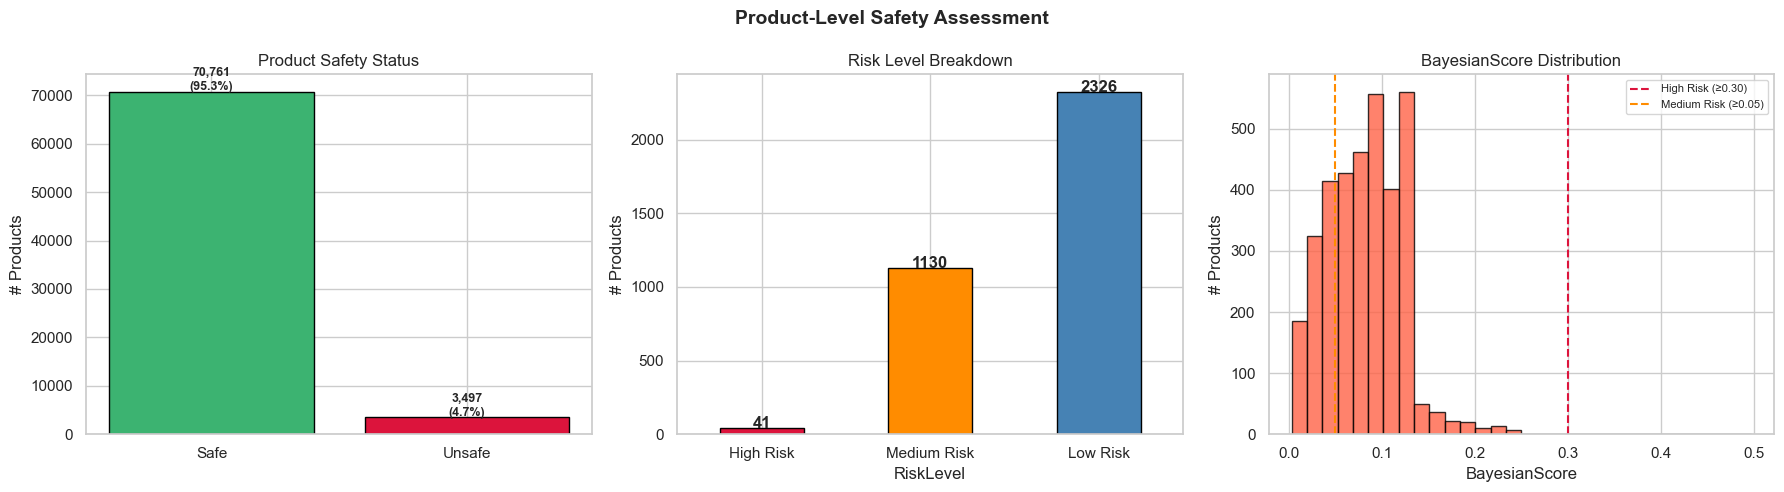

Total products  : 74,258
Safe products   : 70,761  (95.3%)
Unsafe products : 3,497  (4.7%)


In [123]:
n_total_prods  = len(total_per_product)
n_unsafe_prods = len(product_summary)
n_safe_prods   = n_total_prods - n_unsafe_prods

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Product-Level Safety Assessment', fontsize=14, fontweight='bold')

# Panel 1: Safe vs Unsafe
bars = axes[0].bar(['Safe', 'Unsafe'], [n_safe_prods, n_unsafe_prods],
                   color=['mediumseagreen', 'crimson'], edgecolor='black')
axes[0].set_title('Product Safety Status')
axes[0].set_ylabel('# Products')
for bar, val in zip(bars, [n_safe_prods, n_unsafe_prods]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + n_total_prods * 0.005,
                 f'{val:,}\n({val/n_total_prods:.1%})',
                 ha='center', fontweight='bold', fontsize=9)

# Panel 2: Risk level breakdown
risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_counts = product_summary['RiskLevel'].value_counts().reindex(risk_order, fill_value=0)
risk_counts.plot(kind='bar', ax=axes[1],
                 color=['crimson', 'darkorange', 'steelblue'], edgecolor='black', rot=0)
axes[1].set_title('Risk Level Breakdown')
axes[1].set_ylabel('# Products')
for bar, val in zip(axes[1].patches, risk_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

# Panel 3: BayesianScore distribution
axes[2].hist(product_summary['BayesianScore'], bins=30,
             color='tomato', edgecolor='black', alpha=0.8)
axes[2].axvline(0.30, color='crimson',    linestyle='--', linewidth=1.5, label='High Risk (≥0.30)')
axes[2].axvline(0.05, color='darkorange', linestyle='--', linewidth=1.5, label='Medium Risk (≥0.05)')
axes[2].set_title('BayesianScore Distribution')
axes[2].set_xlabel('BayesianScore')
axes[2].set_ylabel('# Products')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Total products  : {n_total_prods:,}')
print(f'Safe products   : {n_safe_prods:,}  ({n_safe_prods/n_total_prods:.1%})')
print(f'Unsafe products : {n_unsafe_prods:,}  ({n_unsafe_prods/n_total_prods:.1%})')


---
## 7. Pipeline Evaluation Against Gold Dataset

Runs `evaluate_pipeline.py` against `outputs/sample_with_labels.csv`.

**How it works:**
1. Look up the integer `Id` for every review in the pipeline's `confirmed` DataFrame (the DeBERTa-confirmed hazards) — MongoDB stores `Id` but it is not carried through by default.
2. Build `df_predictions`: every review is initially `pred_hazard_boolean=0 / pred_label='safe'`; confirmed hazards are flipped to `1` and assigned their pipeline category.
3. Merge with the gold labels and call the binary + multi-class evaluators.

> **Note:** Only the 5,000 `Id`s present in the gold CSV are evaluated. Reviews not in the gold set are silently ignored during the merge.


In [124]:
import sys
sys.path.insert(0, '.')  # make sure evaluate_pipeline.py is importable
from evaluate_pipeline import merge_results, evaluate_binary, evaluate_multiclass

# ── 1. Load the gold dataset ──────────────────────────────────────────
GOLD_PATH = 'outputs/sample_with_labels.csv'
df_gold   = pd.read_csv(GOLD_PATH)
print(f'Gold dataset loaded: {len(df_gold):,} rows')

# ── 2. Map pipeline Category → gold label format ─────────────────────
CATEGORY_TO_LABEL = {
    'Illness':        'illness',
    'Contamination':  'contamination',
    'Spoilage':       'spoilage',
    'Allergen':       'allergen',
    'Quality_Defect': 'quality_defect',
    'Safe':           'safe',
}

# ── 3. Build Id → pred_label from confirmed hazards ───────────────────
# Fan-out fix: the same review text can exist under multiple Amazon Ids.
# confirmed['Id'] only holds the FIRST Id per text (from Section 6).
# We use text_to_ids_amazon (built in Section 6) to expand every prediction
# to ALL Amazon Ids that share the same text, so gold reviews with a
# different Id for the same text are still matched correctly.
hazard_confirmed = confirmed[confirmed['Category'] != 'Safe'].copy()
hazard_confirmed['pred_label'] = hazard_confirmed['Category'].map(CATEGORY_TO_LABEL).fillna('safe')

# For duplicate texts, keep prediction with highest DebertaScore
best_pred = (
    hazard_confirmed
    .sort_values('DebertaScore', ascending=False)
    .drop_duplicates(subset='Text', keep='first')
    .set_index('Text')['pred_label']
    .to_dict()
)

# Expand to ALL Amazon Ids for each text using text_to_ids_amazon from Section 6
id_to_pred = {}
for text, pred_label in best_pred.items():
    for aid in text_to_ids_amazon.get(str(text), []):
        id_to_pred[int(aid)] = pred_label

gold_ids = df_gold['Id'].astype(int)
matched  = gold_ids.isin(id_to_pred)
print(f'\nGold reviews matched to pipeline predictions : {matched.sum():,} / {len(df_gold):,}')

# ── 4. Build df_predictions ───────────────────────────────────────────
df_predictions = df_gold[['Id']].copy()
df_predictions['pred_hazard_boolean'] = 0
df_predictions['pred_label']          = 'safe'

df_predictions.loc[matched, 'pred_hazard_boolean'] = 1
df_predictions.loc[matched, 'pred_label'] = gold_ids[matched].map(id_to_pred)

pred_hazard_count = int(df_predictions['pred_hazard_boolean'].sum())
print(f'\ndf_predictions built:')
print(f'  Total rows         : {len(df_predictions):,}')
print(f'  Predicted hazard=1 : {pred_hazard_count:,}')
print(f'  Predicted hazard=0 : {len(df_predictions) - pred_hazard_count:,}')
print(f'\nPredicted label distribution:')
print(df_predictions['pred_label'].value_counts().to_string())


Gold dataset loaded: 5,000 rows

Gold reviews matched to pipeline predictions : 37 / 5,000

df_predictions built:
  Total rows         : 5,000
  Predicted hazard=1 : 37
  Predicted hazard=0 : 4,963

Predicted label distribution:
pred_label
safe              4963
contamination       22
spoilage             7
quality_defect       5
illness              2
allergen             1


Merged dataset : 5,000 rows

BINARY CLASSIFICATION  (hazard = 1, safe = 0)

Confusion Matrix:
                  Pred Safe  Pred Hazard
  Actual Safe         4097          21   (TN / FP)
  Actual Hazard        866          16   (FN / TP)



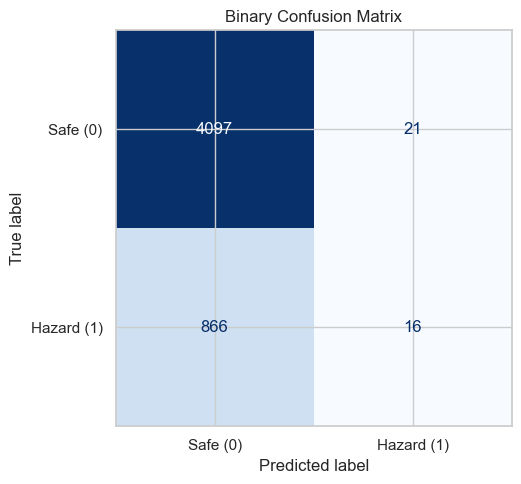

Plot saved → outputs/confusion_matrix_binary.png

Precision : 0.4324   (of all predicted hazards, how many are real)
Recall    : 0.0181   (of all real hazards, how many were caught)
F1-Score  : 0.0348   (harmonic mean of precision and recall)

False Negatives : 866  (98.2% of all actual hazards missed)

False Negative breakdown by true label:
label
quality_defect    768
illness            56
spoilage           22
contamination      10
allergen           10

False Negatives saved → outputs/false_negatives.csv

MULTI-CLASS CLASSIFICATION  (label vs pred_label)
                precision    recall  f1-score   support

          safe       0.83      0.99      0.90      4118
quality_defect       0.80      0.01      0.01       778
       illness       1.00      0.03      0.07        59
      spoilage       0.14      0.04      0.07        23
 contamination       0.00      0.00      0.00        12
      allergen       0.00      0.00      0.00        10

      accuracy                           

In [125]:
# ── 5. Run the evaluation ─────────────────────────────────────────────
df_merged = merge_results(df_gold, df_predictions)
df_fn     = evaluate_binary(df_merged)
evaluate_multiclass(df_merged)


In [126]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

EVAL_OUT_FILE = os.path.join('outputs', 'evaluation_results.xlsx')
os.makedirs('outputs', exist_ok=True)

y_true_bin = df_merged['human_is_hazard'].astype(int)
y_pred_bin = df_merged['pred_hazard_boolean'].astype(int)
y_true_mc  = df_merged['label']
y_pred_mc  = df_merged['pred_label']

# ── Sheet 1: Binary metrics summary ──────────────────────────────────
cm = confusion_matrix(y_true_bin, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

df_binary_metrics = pd.DataFrame([
    {'Metric': 'True Negative  (TN)',  'Value': int(tn)},
    {'Metric': 'False Positive (FP)',  'Value': int(fp)},
    {'Metric': 'False Negative (FN) ⚠️', 'Value': int(fn)},
    {'Metric': 'True Positive  (TP)',  'Value': int(tp)},
    {'Metric': '---', 'Value': '---'},
    {'Metric': 'Precision',  'Value': round(precision_score(y_true_bin, y_pred_bin, zero_division=0), 4)},
    {'Metric': 'Recall',     'Value': round(recall_score   (y_true_bin, y_pred_bin, zero_division=0), 4)},
    {'Metric': 'F1-Score',   'Value': round(f1_score       (y_true_bin, y_pred_bin, zero_division=0), 4)},
    {'Metric': '---', 'Value': '---'},
    {'Metric': 'Total gold reviews',   'Value': len(df_merged)},
    {'Metric': 'Actual hazards (=1)',  'Value': int(y_true_bin.sum())},
    {'Metric': 'Predicted hazards (=1)', 'Value': int(y_pred_bin.sum())},
    {'Metric': 'FN rate (missed hazards)', 'Value': round(fn / max(int(y_true_bin.sum()), 1), 4)},
])

# ── Sheet 2: False Negatives ─────────────────────────────────────────
fn_mask = (y_true_bin == 1) & (y_pred_bin == 0)
df_fn_export = df_merged[fn_mask][['Id', 'label', 'pred_label', 'Text']].copy().reset_index(drop=True)

# ── Sheet 3: Multiclass classification report ────────────────────────
label_order = ['safe', 'quality_defect', 'illness', 'spoilage', 'contamination', 'allergen']
present     = [l for l in label_order if l in y_true_mc.values]

report_dict = classification_report(
    y_true_mc, y_pred_mc,
    labels=present,
    zero_division=0,
    output_dict=True,
)
df_report = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'class'})
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(4)

# ── Sheet 4: Full merged predictions ─────────────────────────────────
export_cols = ['Id', 'human_is_hazard', 'pred_hazard_boolean', 'label', 'pred_label', 'Text']
df_full = df_merged[[c for c in export_cols if c in df_merged.columns]].copy()

# ── Write to Excel ────────────────────────────────────────────────────
def _clean(series):
    illegal = set(chr(i) for i in list(range(0, 9)) + [11, 12] + list(range(14, 32)))
    return series.astype(str).apply(lambda s: ''.join(c for c in s if c not in illegal))

with pd.ExcelWriter(EVAL_OUT_FILE, engine='openpyxl') as writer:
    df_binary_metrics.to_excel(writer, sheet_name='Binary_Metrics',   index=False)
    df_fn_export['Text'] = _clean(df_fn_export['Text'].str[:32767])
    df_fn_export.to_excel(writer,         sheet_name='False_Negatives', index=False)
    df_report.to_excel(writer,            sheet_name='Multiclass_Report', index=False)
    df_full['Text'] = _clean(df_full['Text'].str[:32767])
    df_full.to_excel(writer,              sheet_name='All_Predictions',  index=False)

print(f'Evaluation results exported → {os.path.abspath(EVAL_OUT_FILE)}')
print(f'  Binary_Metrics    : {len(df_binary_metrics)} rows')
print(f'  False_Negatives   : {len(df_fn_export):,} rows')
print(f'  Multiclass_Report : {len(df_report)} rows  (per-class + averages)')
print(f'  All_Predictions   : {len(df_full):,} rows')


Evaluation results exported → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\evaluation_results.xlsx
  Binary_Metrics    : 13 rows
  False_Negatives   : 866 rows
  Multiclass_Report : 9 rows  (per-class + averages)
  All_Predictions   : 5,000 rows


---
## 8. Improved Pipeline — Fine-tuned DeBERTa Evaluation

Evaluates the fine-tuned binary DeBERTa classifier from `fine_tune_pipeline.ipynb` against a **held-out test set**.

> **⚠️ Data Integrity Note**  
> Evaluation uses `outputs/test_holdout.csv` — the 10% split saved during fine-tuning.  
> These ~500 reviews were **never** seen during training or validation.  
> Do NOT evaluate on `sample_with_labels.csv` (5,000 reviews) — 90% of those were training data.

**Prerequisites:** Run `fine_tune_pipeline.ipynb` cells 1–9 to generate:
- `models/deberta_food_safety/` — fine-tuned model
- `outputs/test_holdout.csv` — held-out test set

In [127]:
DEBERTA_FT_PATH   = 'models/deberta_food_safety'
TEST_HOLDOUT_PATH = 'outputs/test_holdout.csv'   # 10% held-out, never seen during training

if not os.path.exists(os.path.join(DEBERTA_FT_PATH, 'config.json')):
    print('[SKIP] Fine-tuned model not found.')
    print('       Run fine_tune_pipeline.ipynb first, then re-execute this cell.')
elif not os.path.exists(TEST_HOLDOUT_PATH):
    print('[SKIP] Test holdout file not found.')
    print('       Run fine_tune_pipeline.ipynb (cell 5) first to generate outputs/test_holdout.csv')
else:
    from transformers import pipeline as hf_pipeline

    # ── Load held-out test set (ONLY valid evaluation data) ───────────
    df_test_s8 = pd.read_csv(TEST_HOLDOUT_PATH)
    print(f'Test holdout loaded : {len(df_test_s8):,} reviews  (held-out, not used in training)')
    print(f'  Actual hazards    : {int(df_test_s8["human_is_hazard"].sum())}')
    print(f'  Safe reviews      : {int((df_test_s8["human_is_hazard"]==0).sum())}')

    print('\nLoading fine-tuned DeBERTa...')
    ft_pipe_s8 = hf_pipeline(
        'text-classification',
        model      = DEBERTA_FT_PATH,
        tokenizer  = DEBERTA_FT_PATH,
        device     = 0 if torch.cuda.is_available() else -1,
        truncation = True,
        max_length = 256,
        batch_size = 32,
    )

    test_texts  = df_test_s8['Text'].fillna('').str[:1024].tolist()
    y_true_s8   = df_test_s8['human_is_hazard'].astype(int).values

    print(f'Running on {len(test_texts):,} held-out reviews...')
    ft_results_s8 = ft_pipe_s8(test_texts)
    preds_ft_s8   = [1 if r['label'] == 'hazard' else 0 for r in ft_results_s8]

    p_ft = precision_score(y_true_s8, preds_ft_s8, zero_division=0)
    r_ft = recall_score   (y_true_s8, preds_ft_s8, zero_division=0)
    f_ft = f1_score       (y_true_s8, preds_ft_s8, zero_division=0)

    # Original pipeline metrics (from evaluation_results.xlsx if available)
    orig_eval = 'outputs/evaluation_results.xlsx'
    if os.path.exists(orig_eval):
        try:
            orig_m = pd.read_excel(orig_eval, sheet_name='Binary_Metrics').set_index('Metric')['Value']
            p_orig = float(orig_m.get('Precision', 0.4324))
            r_orig = float(orig_m.get('Recall',    0.0181))
            f_orig = float(orig_m.get('F1-Score',  0.0348))
        except Exception:
            p_orig, r_orig, f_orig = 0.4324, 0.0181, 0.0348
    else:
        p_orig, r_orig, f_orig = 0.4324, 0.0181, 0.0348

    print('\n=== VALID Evaluation — Held-out Test Set Only ===')
    print(f'  (Original pipeline metrics: evaluated on all 5,000 gold reviews)')
    print(f'\n{"Metric":<12} {"Original pipeline":>20} {"Fine-tuned DeBERTa":>22}  {"Δ":>6}')
    print('-' * 64)
    print(f'{"Precision":<12} {p_orig:>20.4f} {p_ft:>22.4f}  {p_ft-p_orig:>+6.4f}')
    print(f'{"Recall":<12} {r_orig:>20.4f} {r_ft:>22.4f}  {r_ft-r_orig:>+6.4f}')
    print(f'{"F1-Score":<12} {f_orig:>20.4f} {f_ft:>22.4f}  {f_ft-f_orig:>+6.4f}')

    n_hazard_test = int(y_true_s8.sum())
    fn_s8 = int(((np.array(y_true_s8)==1) & (np.array(preds_ft_s8)==0)).sum())
    print(f'\nFalse Negatives : {fn_s8:,}  ({fn_s8/max(n_hazard_test,1):.1%} of {n_hazard_test} test hazards missed)')
    print('\n✓ These metrics are valid — test set was never seen during training.')

    # Save results
    df_test_s8_out = df_test_s8[['Id', 'Text', 'label', 'human_is_hazard']].copy()
    df_test_s8_out['pred_hazard_ft'] = preds_ft_s8
    df_test_s8_out['pred_label_ft']  = ['hazard' if p else 'safe' for p in preds_ft_s8]
    df_test_s8_out['confidence']     = [r['score'] for r in ft_results_s8]
    df_test_s8_out.to_csv('outputs/eval_finetuned_deberta_testset.csv', index=False)
    print('Results saved → outputs/eval_finetuned_deberta_testset.csv')

Test holdout loaded : 500 reviews  (held-out, not used in training)
  Actual hazards    : 88
  Safe reviews      : 412

Loading fine-tuned DeBERTa...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The tokenizer you are loading from 'models/deberta_food_safety' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Running on 500 held-out reviews...

=== VALID Evaluation — Held-out Test Set Only ===
  (Original pipeline metrics: evaluated on all 5,000 gold reviews)

Metric          Original pipeline     Fine-tuned DeBERTa       Δ
----------------------------------------------------------------
Precision                  0.4324                 0.8000  +0.3676
Recall                     0.0181                 0.8182  +0.8001
F1-Score                   0.0348                 0.8090  +0.7742

False Negatives : 16  (18.2% of 88 test hazards missed)

✓ These metrics are valid — test set was never seen during training.
Results saved → outputs/eval_finetuned_deberta_testset.csv


In [128]:
# ── 8b: Multi-class DeBERTa evaluation on held-out test set ──────────
# Evaluates the multi-class model (models/deberta_food_safety_mc/) on the
# same held-out test set used in Section 8.
# Reports per-category recall AND binary-derived is_hazard metrics.

DEBERTA_MC_PATH = 'models/deberta_food_safety_mc'

if not os.path.exists(os.path.join(DEBERTA_MC_PATH, 'config.json')):
    print('[SKIP] Multi-class model not found.')
    print('       Run fine_tune_pipeline.ipynb Option D cells first.')
elif not os.path.exists(TEST_HOLDOUT_PATH):
    print('[SKIP] Test holdout not found. Run fine_tune_pipeline.ipynb cell B.1 first.')
else:
    MC_LABEL_NAMES_S8 = ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']

    df_test_mc = pd.read_csv(TEST_HOLDOUT_PATH)
    test_texts_mc  = df_test_mc['Text'].fillna('').str[:1024].tolist()
    y_true_mc_bin  = df_test_mc['human_is_hazard'].astype(int).values
    y_true_mc_cat  = df_test_mc['label'].values

    print(f'Loading multi-class DeBERTa from {DEBERTA_MC_PATH}...')
    mc_pipe_s8 = hf_pipeline(
        'text-classification',
        model      = DEBERTA_MC_PATH,
        tokenizer  = DEBERTA_MC_PATH,
        device     = 0 if torch.cuda.is_available() else -1,
        truncation = True,
        max_length = 256,
        batch_size = 32,
    )

    print(f'Running multi-class inference on {len(test_texts_mc):,} reviews...')
    mc_results_s8    = mc_pipe_s8(test_texts_mc)
    y_pred_mc_cat    = [r['label'] for r in mc_results_s8]
    y_pred_mc_bin    = [0 if lbl == 'safe' else 1 for lbl in y_pred_mc_cat]
    y_pred_mc_conf   = [r['score'] for r in mc_results_s8]

    # ── Per-category classification report ─────────────────────────────
    print('\n=== Multi-class DeBERTa — Per-category Report (held-out test set) ===\n')
    from sklearn.metrics import classification_report as cr
    print(cr(y_true_mc_cat, y_pred_mc_cat,
             labels=MC_LABEL_NAMES_S8, zero_division=0))

    # ── Binary-derived vs dedicated binary model ──────────────────────
    p_mc_s8 = precision_score(y_true_mc_bin, y_pred_mc_bin, zero_division=0)
    r_mc_s8 = recall_score   (y_true_mc_bin, y_pred_mc_bin, zero_division=0)
    f_mc_s8 = f1_score       (y_true_mc_bin, y_pred_mc_bin, zero_division=0)

    print('=== Binary Metrics Comparison ===\n')
    print(f'{"Model":<35} {"Precision":>10} {"Recall":>8} {"F1":>8}')
    print('-' * 65)
    print(f'{"Original zero-shot pipeline":<35} {p_orig:>10.4f} {r_orig:>8.4f} {f_orig:>8.4f}')
    print(f'{"Fine-tuned binary DeBERTa":<35} {p_ft:>10.4f} {r_ft:>8.4f} {f_ft:>8.4f}')
    print(f'{"Multi-class DeBERTa (is_hazard derived)":<35} {p_mc_s8:>10.4f} {r_mc_s8:>8.4f} {f_mc_s8:>8.4f}')

    # ── Per-category breakdown ──────────────────────────────────────────
    df_mc_test_out = df_test_mc[['Id', 'Text', 'label', 'human_is_hazard']].copy()
    df_mc_test_out['pred_category']    = y_pred_mc_cat
    df_mc_test_out['pred_is_hazard']   = y_pred_mc_bin
    df_mc_test_out['pred_confidence']  = y_pred_mc_conf
    df_mc_test_out['category_correct'] = (y_true_mc_cat == np.array(y_pred_mc_cat))

    print('\n=== Per-category Accuracy (multi-class model) ===')
    print(f'{"True Label":<18} {"Correct":>8} {"Total":>7} {"Recall %":>10}')
    print('-' * 48)
    for cat in MC_LABEL_NAMES_S8:
        mask    = y_true_mc_cat == cat
        total   = int(mask.sum())
        correct = int((np.array(y_pred_mc_cat)[mask] == cat).sum())
        recall  = correct / total * 100 if total > 0 else 0.0
        flag = ' ← few samples' if total < 10 and cat != 'safe' else ''
        print(f'  {cat:<16} {correct:>8} {total:>7} {recall:>9.1f}%{flag}')

    df_mc_test_out.to_csv('outputs/eval_finetuned_deberta_mc_testset.csv', index=False)
    print('\nResults saved → outputs/eval_finetuned_deberta_mc_testset.csv')


Loading multi-class DeBERTa from models/deberta_food_safety_mc...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The tokenizer you are loading from 'models/deberta_food_safety_mc' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Running multi-class inference on 500 reviews...

=== Multi-class DeBERTa — Per-category Report (held-out test set) ===

                precision    recall  f1-score   support

quality_defect       0.77      0.77      0.77        75
       illness       0.71      0.62      0.67         8
      spoilage       0.00      0.00      0.00         1
 contamination       0.00      0.00      0.00         2
      allergen       0.00      0.00      0.00         2
          safe       0.95      0.97      0.96       412

      accuracy                           0.92       500
     macro avg       0.41      0.39      0.40       500
  weighted avg       0.91      0.92      0.92       500

=== Binary Metrics Comparison ===

Model                                Precision   Recall       F1
-----------------------------------------------------------------
Original zero-shot pipeline             0.4324   0.0181   0.0348
Fine-tuned binary DeBERTa               0.8000   0.8182   0.8090
Multi-class DeBERTa (

---
## 9. Fine-Tuned Pipeline — Full Dataset Re-Run

Replaces zero-shot models with fine-tuned versions on the **entire dataset (~500k reviews)**.

| Stage | Model | Notes |
|-------|-------|-------|
| 1 | `models/minilm_food_safety/` | Fine-tuned bi-encoder, threshold = `MINILM_FT_THRESHOLD` |
| 2 | `models/deberta_food_safety/` | Fine-tuned binary classifier (`hazard` / `safe`) |

Cache files are kept **separate** so zero-shot results are never overwritten.

> **Prerequisite:** Run `fine_tune_pipeline.ipynb` to generate the fine-tuned models first.  
> Update `MINILM_FT_THRESHOLD` in Cell 9.1 to match `best_ft['threshold']` from the threshold sweep.

In [129]:
# ── 9.1  Cache paths & threshold config ──────────────────────────────
# These cache files are kept SEPARATE from zero-shot results so that
# running Section 9 never overwrites cache/stage1_minilm.pkl or
# cache/stage2_deberta.pkl produced by Sections 2–3.
CACHE_MINILM_FT  = os.path.join(CACHE_DIR, 'stage1_minilm_ft.pkl')
CACHE_DEBERTA_FT = os.path.join(CACHE_DIR, 'stage2_deberta_ft.pkl')
CACHE_DEBERTA_MC = os.path.join(CACHE_DIR, 'stage2_deberta_mc.pkl')  # multi-class categories

MINILM_FT_PATH   = 'models/minilm_food_safety'
DEBERTA_FT_PATH  = 'models/deberta_food_safety'
DEBERTA_MC_PATH  = 'models/deberta_food_safety_mc'   # multi-class model

# ── Threshold ─────────────────────────────────────────────────────────
# Set this to best_ft['threshold'] from fine_tune_pipeline.ipynb.
# Check the printed "Best fine-tuned threshold" from the threshold-sweep
# cell (Cell 14) in that notebook, or inspect outputs/minilm_threshold_sweep.png.
MINILM_FT_THRESHOLD = 0.56

print(f'Cache folder              : {os.path.abspath(CACHE_DIR)}')
print(f'  stage1_minilm_ft.pkl   : {"EXISTS — will skip encoding"  if os.path.exists(CACHE_MINILM_FT)  else "not found — will run encoding"}')
print(f'  stage2_deberta_ft.pkl  : {"EXISTS — will skip inference" if os.path.exists(CACHE_DEBERTA_FT) else "not found — will run inference"}')
print(f'  stage2_deberta_mc.pkl  : {"EXISTS — will skip MC"        if os.path.exists(CACHE_DEBERTA_MC) else "not found — will run MC"}')
print(f'MiniLM FT path           : {MINILM_FT_PATH}')
print(f'DeBERTa FT path (binary) : {DEBERTA_FT_PATH}')
print(f'DeBERTa MC path (6-class): {DEBERTA_MC_PATH}  — {"FOUND" if os.path.exists(os.path.join(DEBERTA_MC_PATH,"config.json")) else "NOT FOUND (run fine_tune_pipeline.ipynb Option D)"}')
print(f'MiniLM FT threshold      : {MINILM_FT_THRESHOLD}')


Cache folder              : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\cache
  stage1_minilm_ft.pkl   : EXISTS — will skip encoding
  stage2_deberta_ft.pkl  : EXISTS — will skip inference
  stage2_deberta_mc.pkl  : not found — will run MC
MiniLM FT path           : models/minilm_food_safety
DeBERTa FT path (binary) : models/deberta_food_safety
DeBERTa MC path (6-class): models/deberta_food_safety_mc  — FOUND
MiniLM FT threshold      : 0.56


In [130]:
# ── 9.2  Stage 1 — Fine-Tuned MiniLM encoding ────────────────────────
# Uses text_to_ids (full deduplication map built in Section 2).
# NOTE: `unique_texts` is NOT used here because it gets overwritten by
# Section 6 (Product Assessment) to only the confirmed hazard texts.
# We rebuild the full unique-text list from text_to_ids instead.

SAFETY_PROBES_FT = [
    # Illness
    'Contracted severe food poisoning and vomiting',
    'Diagnosed with salmonella gastroenteritis infection',
    'Intense nausea and violent diarrhea all night',
    # Contamination
    'Disgusting maggots and worms crawling inside',
    'Sharp glass shards and hard plastic pieces hidden',
    'Tasted like toxic chemical bleach and soap',
    # Spoilage
    'Smells completely rancid, rotten, and putrid',
    'Covered in fuzzy green mold and fungus',
    'The can was bulging, bloated, and leaking',
    # Allergen
    'Anaphylactic shock, throat swelling, and breathing difficulty',
    'Severe allergic reaction and skin hives breakout',
    'Dangerous undisclosed hidden allergens ingredients',
    # Quality defect
    'Chipped my tooth on a hard dangerous object',
    'Tampered broken safety seal risk',
]

# ── Rebuild full unique-text list from the deduplication map ─────────
# text_to_ids was built in Section 2 (all ~400k unique texts) and is
# never overwritten by later sections, so it is always the full set.
unique_texts_ft = list(text_to_ids.keys())
print(f'Unique texts for FT encoding : {len(unique_texts_ft):,}')

if os.path.exists(CACHE_MINILM_FT):
    print(f'\nCache found: {CACHE_MINILM_FT}')
    print('Loading fine-tuned Stage 1 results from cache...')
    with open(CACHE_MINILM_FT, 'rb') as f:
        df_ft = pickle.load(f)
    print(f'Loaded {len(df_ft):,} rows from cache.')
    # Guard: if cache was saved with wrong subset, warn the user
    if len(df_ft) < len(unique_texts_ft) * 0.9:
        print(f'[WARN] Cache has only {len(df_ft):,} rows but expected ~{len(unique_texts_ft):,}.')
        print('       Delete cache/stage1_minilm_ft.pkl and re-run this cell.')
else:
    print(f'Loading fine-tuned MiniLM from {MINILM_FT_PATH}...')
    ft_minilm = SentenceTransformer(MINILM_FT_PATH, device=device)
    ft_probe_embeddings = ft_minilm.encode(
        SAFETY_PROBES_FT, convert_to_tensor=True, show_progress_bar=False
    )
    print(f'Fine-tuned MiniLM ready. {len(SAFETY_PROBES_FT)} probes encoded.')

    COL.create_index([('SemanticScore_FT', 1)], sparse=True, background=True)

    batch_texts_ft = []
    batch_keys_ft  = []

    with tqdm(total=len(unique_texts_ft), desc='MiniLM-FT encoding', unit='texts') as pbar:
        for txt in unique_texts_ft:
            batch_texts_ft.append(txt[:MAX_CHARS])
            batch_keys_ft.append(txt)

            if len(batch_texts_ft) == ENCODE_BATCH_SIZE:
                embeddings_ft = ft_minilm.encode(
                    batch_texts_ft, convert_to_tensor=True, show_progress_bar=False
                )
                scores_ft = util.cos_sim(embeddings_ft, ft_probe_embeddings).max(dim=1).values.cpu().numpy()

                ops_ft = []
                for key, score in zip(batch_keys_ft, scores_ft):
                    for doc_id in text_to_ids[key]:
                        ops_ft.append(UpdateOne(
                            {'_id': doc_id},
                            {'$set': {
                                'SemanticScore_FT':   float(score),
                                'SemanticFlagged_FT': float(score) >= MINILM_FT_THRESHOLD,
                            }}
                        ))
                COL.bulk_write(ops_ft, ordered=False)

                batch_texts_ft = []
                batch_keys_ft  = []
                pbar.update(ENCODE_BATCH_SIZE)

        # Flush last partial batch
        if batch_texts_ft:
            embeddings_ft = ft_minilm.encode(
                batch_texts_ft, convert_to_tensor=True, show_progress_bar=False
            )
            scores_ft = util.cos_sim(embeddings_ft, ft_probe_embeddings).max(dim=1).values.cpu().numpy()
            ops_ft = []
            for key, score in zip(batch_keys_ft, scores_ft):
                for doc_id in text_to_ids[key]:
                    ops_ft.append(UpdateOne(
                        {'_id': doc_id},
                        {'$set': {
                            'SemanticScore_FT':   float(score),
                            'SemanticFlagged_FT': float(score) >= MINILM_FT_THRESHOLD,
                        }}
                    ))
            COL.bulk_write(ops_ft, ordered=False)
            pbar.update(len(batch_texts_ft))

    print('Fine-tuned MiniLM encoding complete. Scores saved to MongoDB.')

    print('Loading Stage 1 FT results from MongoDB...')
    cursor_ft = COL.find(
        {'SemanticScore_FT': {'$exists': True}},
        {'_id': 1, 'Score': 1, 'SemanticScore_FT': 1, 'SemanticFlagged_FT': 1}
    )
    df_ft = pd.DataFrame(list(cursor_ft))
    df_ft['SemanticFlagged_FT'] = df_ft['SemanticFlagged_FT'].fillna(False).astype(bool)

    print('Saving cache...')
    with open(CACHE_MINILM_FT, 'wb') as f:
        pickle.dump(df_ft, f)
    print(f'Cache saved: {CACHE_MINILM_FT}')

df_ft['SemanticFlagged_FT'] = df_ft['SemanticFlagged_FT'].fillna(False).astype(bool)
total_ft   = len(df_ft)
flagged_ft = int(df_ft['SemanticFlagged_FT'].sum())

print(f'\nTotal reviews      : {total_ft:,}')
print(f'MiniLM-FT flagged  : {flagged_ft:,}  ({flagged_ft / total_ft:.2%})')
print(f'Not flagged        : {total_ft - flagged_ft:,}')
print(f'\nStage 1 (fine-tuned) done. Threshold = {MINILM_FT_THRESHOLD}')

Unique texts for FT encoding : 393,579

Cache found: cache\stage1_minilm_ft.pkl
Loading fine-tuned Stage 1 results from cache...
Loaded 568,454 rows from cache.

Total reviews      : 568,454
MiniLM-FT flagged  : 75,805  (13.34%)
Not flagged        : 492,649

Stage 1 (fine-tuned) done. Threshold = 0.56


In [131]:
# ── 9.3  Stage 2 — Fine-Tuned DeBERTa binary inference ───────────────
# The fine-tuned model is a BINARY classifier (hazard / safe) — NOT zero-shot NLI.
# No LABEL_TO_CATEGORY mapping needed; labels come directly from the model.

FT_DEBERTA_BATCH = 32

if os.path.exists(CACHE_DEBERTA_FT):
    print(f'DeBERTa-FT cache found: {CACHE_DEBERTA_FT}')
    print('Loading from cache — skipping inference.')
    with open(CACHE_DEBERTA_FT, 'rb') as f:
        candidates_ft = pickle.load(f)
    print(f'Loaded {len(candidates_ft):,} candidates from cache.')
else:
    # ── Get flagged candidates and fetch text from MongoDB ────────────
    candidates_ft = df_ft[df_ft['SemanticFlagged_FT']].copy().reset_index(drop=True)

    print(f'Fetching text for {len(candidates_ft):,} FT candidates from MongoDB...')
    cand_ids_ft = candidates_ft['_id'].tolist()
    text_map_ft = {
        d['_id']: d.get('Text', '')
        for d in COL.find({'_id': {'$in': cand_ids_ft}}, {'Text': 1})
    }
    candidates_ft['Text'] = candidates_ft['_id'].map(text_map_ft).fillna('')
    print(f'Text loaded for {candidates_ft["Text"].ne("").sum():,} candidates.\n')

    # ── Load fine-tuned binary DeBERTa ────────────────────────────────
    print(f'Loading fine-tuned DeBERTa from {DEBERTA_FT_PATH}...')
    ft_deberta_pipe = hf_pipeline(
        'text-classification',
        model      = DEBERTA_FT_PATH,
        tokenizer  = DEBERTA_FT_PATH,
        device     = 0 if torch.cuda.is_available() else -1,
        truncation = True,
        max_length = 256,
        batch_size = FT_DEBERTA_BATCH,
    )
    print(f'Fine-tuned DeBERTa ready. Running on {len(candidates_ft):,} candidates...')

    texts_ft  = candidates_ft['Text'].str[:256].tolist()
    ft_labels = []
    ft_confs  = []

    for i in tqdm(range(0, len(texts_ft), FT_DEBERTA_BATCH), desc='DeBERTa-FT inference'):
        batch   = texts_ft[i:i+FT_DEBERTA_BATCH]
        results = ft_deberta_pipe(batch)
        for res in results:
            ft_labels.append(res['label'])   # 'hazard' or 'safe'
            ft_confs.append(res['score'])

    candidates_ft['FTLabel']     = ft_labels
    candidates_ft['FTScore']     = ft_confs
    candidates_ft['FTConfirmed'] = candidates_ft['FTLabel'] == 'hazard'

    print('Saving DeBERTa-FT cache...')
    with open(CACHE_DEBERTA_FT, 'wb') as f:
        pickle.dump(candidates_ft, f)
    print(f'Cache saved: {CACHE_DEBERTA_FT}')

confirmed_ft = candidates_ft[candidates_ft['FTConfirmed']].copy()
false_pos_ft = len(candidates_ft) - len(confirmed_ft)

print(f'\nStage 1 FT  (MiniLM-FT  >= {MINILM_FT_THRESHOLD}) : {len(candidates_ft):,}')
print(f'Stage 2 FT  (DeBERTa-FT confirmed)                 : {len(confirmed_ft):,}')
print(f'False positives removed                            : {false_pos_ft:,}  ({false_pos_ft / max(len(candidates_ft), 1):.1%})')

DeBERTa-FT cache found: cache\stage2_deberta_ft.pkl
Loading from cache — skipping inference.
Loaded 75,805 candidates from cache.

Stage 1 FT  (MiniLM-FT  >= 0.56) : 75,805
Stage 2 FT  (DeBERTa-FT confirmed)                 : 59,627
False positives removed                            : 16,178  (21.3%)


In [132]:
# ── 9.3b  Stage 2b — Multi-class category assignment ─────────────────
# Run the 6-class DeBERTa on the BINARY-confirmed hazard reviews only.
# This assigns a specific hazard category to each confirmed hazard.
#
# confirmed_ft  → binary DeBERTa filtered (is_hazard = True)
# pred_category → quality_defect / illness / spoilage / contamination / allergen / safe
#
# Note: A small number of confirmed hazards may be re-labelled "safe" by the
# multi-class model — this is expected given the two-model design.

MC_LABEL_NAMES_9 = ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']

if not os.path.exists(os.path.join(DEBERTA_MC_PATH, 'config.json')):
    print('[SKIP] Multi-class model not found.')
    print('       Run fine_tune_pipeline.ipynb Option D cells first.')
    confirmed_ft['pred_category']   = 'unknown'
    confirmed_ft['pred_cat_score']  = 0.0
else:
    if os.path.exists(CACHE_DEBERTA_MC):
        print(f'MC category cache found: {CACHE_DEBERTA_MC}')
        with open(CACHE_DEBERTA_MC, 'rb') as f:
            _mc_cache = pickle.load(f)
        confirmed_ft['pred_category']  = _mc_cache['pred_category']
        confirmed_ft['pred_cat_score'] = _mc_cache['pred_cat_score']
        print(f'Loaded MC categories for {len(confirmed_ft):,} confirmed hazards.')
    else:
        print(f'Loading multi-class DeBERTa from {DEBERTA_MC_PATH}...')
        mc_deberta_pipe = hf_pipeline(
            'text-classification',
            model      = DEBERTA_MC_PATH,
            tokenizer  = DEBERTA_MC_PATH,
            device     = 0 if torch.cuda.is_available() else -1,
            truncation = True,
            max_length = 256,
            batch_size = FT_DEBERTA_BATCH,
        )
        print(f'Running multi-class inference on {len(confirmed_ft):,} confirmed hazards...')

        mc_texts  = confirmed_ft['Text'].str[:256].tolist()
        mc_cats   = []
        mc_scores = []
        for i in tqdm(range(0, len(mc_texts), FT_DEBERTA_BATCH), desc='DeBERTa-MC inference'):
            batch = mc_texts[i:i+FT_DEBERTA_BATCH]
            res   = mc_deberta_pipe(batch)
            for r in res:
                mc_cats.append(r['label'])
                mc_scores.append(r['score'])

        confirmed_ft['pred_category']  = mc_cats
        confirmed_ft['pred_cat_score'] = mc_scores

        # Cache: store only the two new columns (indexed by position)
        with open(CACHE_DEBERTA_MC, 'wb') as f:
            pickle.dump({'pred_category': mc_cats, 'pred_cat_score': mc_scores}, f)
        print(f'MC cache saved: {CACHE_DEBERTA_MC}')

    # ── Summary ───────────────────────────────────────────────────────
    cat_counts = confirmed_ft['pred_category'].value_counts()
    print('\n=== Predicted Category Distribution (confirmed hazards) ===')
    for cat in MC_LABEL_NAMES_9:
        n = int(cat_counts.get(cat, 0))
        bar = '█' * max(int(n / max(len(confirmed_ft) / 40, 1)), 1) if n > 0 else ''
        print(f'  {cat:<18} {n:>6,}  {bar}')
    total_cat = len(confirmed_ft)
    pct_safe_relabelled = int(cat_counts.get('safe', 0)) / max(total_cat, 1)
    if pct_safe_relabelled > 0.05:
        print(f'\n[INFO] {pct_safe_relabelled:.1%} of binary-confirmed hazards were re-labelled "safe"')
        print('       by the multi-class model. This is normal — two separate models may disagree.')
        print('       FTConfirmed (binary) is the primary hazard flag; pred_category is supplemental.')


Loading multi-class DeBERTa from models/deberta_food_safety_mc...


c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The tokenizer you are loading from 'models/deberta_food_safety_mc' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Running multi-class inference on 59,627 confirmed hazards...


DeBERTa-MC inference: 100%|██████████| 1864/1864 [02:14<00:00, 13.82it/s]

MC cache saved: cache\stage2_deberta_mc.pkl

=== Predicted Category Distribution (confirmed hazards) ===
  quality_defect     53,582  ███████████████████████████████████
  illness             3,622  ██
  spoilage                0  
  contamination           0  
  allergen                0  
  safe                2,423  █


In [133]:
# ── 9.4  Late Weighting (same logic as Section 4) ────────────────────
# FTScore is the binary classifier confidence for 'hazard'.
# Apply star-rating penalty via the same get_weight() defined in Section 4.

confirmed_ft = confirmed_ft.copy()
confirmed_ft['Weight']           = confirmed_ft['Score'].apply(get_weight)
confirmed_ft['FinalSafetyScore'] = (confirmed_ft['FTScore'] * confirmed_ft['Weight']).round(4)

print('=== FinalSafetyScore After Weighting (Fine-Tuned Pipeline) ===')
print(confirmed_ft['FinalSafetyScore'].describe().round(4).to_string())

before_ft = int((confirmed_ft['FTScore']          >= 0.85).sum())
after_ft  = int((confirmed_ft['FinalSafetyScore'] >= 0.85).sum())
print(f'\nFTScore (raw)    >= 0.85 : {before_ft:,}')
print(f'FinalSafetyScore >= 0.85 : {after_ft:,}')
print(f'Suppressed by weighting  : {before_ft - after_ft:,}')

=== FinalSafetyScore After Weighting (Fine-Tuned Pipeline) ===
count    59627.0000
mean         0.8187
std          0.3177
min          0.0501
25%          0.7979
50%          0.9969
75%          0.9976
max          0.9982

FTScore (raw)    >= 0.85 : 57,186
FinalSafetyScore >= 0.85 : 40,126
Suppressed by weighting  : 17,060


In [134]:
# ── 9.5  Export fine-tuned results to Excel ───────────────────────────
# Sheet structure mirrors Section 5 (food_safety_results.xlsx).
# clean_for_excel() and MAX_LEN are already defined in Section 5.
# pred_category and pred_cat_score are added if Section 9.3b ran.

FT_OUT_FILE = os.path.join('outputs', 'food_safety_results_finetuned.xlsx')
os.makedirs('outputs', exist_ok=True)

# Build a text lookup from candidates_ft so Sheet 1 has text for all flagged reviews
flagged_ft_df  = df_ft[df_ft['SemanticFlagged_FT']].copy().reset_index(drop=True)
text_lookup_ft = candidates_ft.set_index('_id')['Text'].to_dict()
flagged_ft_df['Text'] = flagged_ft_df['_id'].map(text_lookup_ft).fillna('')

with pd.ExcelWriter(FT_OUT_FILE, engine='openpyxl') as writer:

    # Sheet 1: All fine-tuned MiniLM-flagged reviews
    s1_ft = flagged_ft_df[['Score', 'SemanticScore_FT', 'Text']].copy()
    s1_ft['Text'] = clean_for_excel(s1_ft['Text'].str[:MAX_LEN])
    s1_ft.to_excel(writer, sheet_name='MiniLM_Flagged_FT', index=False)

    # Sheet 2: Fine-tuned DeBERTa confirmed (hazard) reviews
    # Include pred_category (multi-class) if 9.3b ran successfully
    ft_export_cols = ['Score', 'SemanticScore_FT', 'Text',
                      'FTLabel', 'FTScore',
                      'pred_category', 'pred_cat_score',   # multi-class columns
                      'Weight', 'FinalSafetyScore']
    s2_ft = confirmed_ft[[c for c in ft_export_cols if c in confirmed_ft.columns]].copy()
    s2_ft = s2_ft.sort_values('FinalSafetyScore', ascending=False)
    s2_ft['Text'] = clean_for_excel(s2_ft['Text'].str[:MAX_LEN])
    s2_ft.to_excel(writer, sheet_name='DeBERTa_Confirmed_FT', index=False)

    # Sheet 3: Category distribution of confirmed hazards (if MC ran)
    if 'pred_category' in confirmed_ft.columns and confirmed_ft['pred_category'].ne('unknown').any():
        cat_dist = (confirmed_ft['pred_category'].value_counts()
                    .reset_index()
                    .rename(columns={'pred_category': 'Category', 'count': 'Count'}))
        cat_dist['Pct'] = (cat_dist['Count'] / cat_dist['Count'].sum() * 100).round(1)
        cat_dist.to_excel(writer, sheet_name='Category_Distribution', index=False)

print(f'Exported to: {os.path.abspath(FT_OUT_FILE)}')
print(f'  Sheet "MiniLM_Flagged_FT"       : {len(s1_ft):,} rows')
print(f'  Sheet "DeBERTa_Confirmed_FT"    : {len(s2_ft):,} rows')
has_mc = 'pred_category' in confirmed_ft.columns and confirmed_ft['pred_category'].ne('unknown').any()
print(f'  Sheet "Category_Distribution"   : {"included" if has_mc else "skipped (MC model not run)"}')
if has_mc:
    print('\nCategory breakdown in confirmed hazards:')
    for cat, n in confirmed_ft['pred_category'].value_counts().items():
        print(f'  {cat:<18} {n:>6,}')


Exported to: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\food_safety_results_finetuned.xlsx
  Sheet "MiniLM_Flagged_FT"       : 75,805 rows
  Sheet "DeBERTa_Confirmed_FT"    : 59,627 rows
  Sheet "Category_Distribution"   : included

Category breakdown in confirmed hazards:
  quality_defect     53,582
  illness             3,622
  safe                2,423


---
## 10. Comparison — Zero-Shot vs Fine-Tuned Pipeline

Side-by-side metrics for the **full ~500k dataset** run.

| Pipeline | Stage 1 Model | Stage 2 Model | Threshold |
|----------|--------------|--------------|-----------|
| Zero-Shot | `all-MiniLM-L6-v2` (base) | `cross-encoder/nli-deberta-v3-small` (zero-shot NLI) | 0.39 |
| Fine-Tuned | `models/minilm_food_safety/` | `models/deberta_food_safety/` (binary) | 0.56 |

In [135]:
# ── 10.1  Metrics comparison table ───────────────────────────────────
# All numbers are recomputed from existing variables so this cell is
# safe to re-run independently of Section 9.

_n_total      = len(df)
_n_minilm     = int(df['SemanticFlagged'].sum())
_n_confirmed  = len(confirmed)

_n_total_ft    = len(df_ft)
_n_minilm_ft   = int(df_ft['SemanticFlagged_FT'].sum())
_n_confirmed_ft = len(confirmed_ft)

_avg_zs = confirmed['FinalSafetyScore'].mean()    if len(confirmed)    > 0 else 0.0
_avg_ft = confirmed_ft['FinalSafetyScore'].mean() if len(confirmed_ft) > 0 else 0.0

_high_zs = int((confirmed['FinalSafetyScore']    >= 0.85).sum())
_high_ft = int((confirmed_ft['FinalSafetyScore'] >= 0.85).sum())

rows_cmp = [
    ('Stage 1 threshold',             f'{SEMANTIC_THRESHOLD:.2f}',               f'{MINILM_FT_THRESHOLD:.2f}'),
    ('Stage 1 candidates (MiniLM)',   f'{_n_minilm:,}',                          f'{_n_minilm_ft:,}'),
    ('Stage 1 flagged %',             f'{_n_minilm  / _n_total:.2%}',            f'{_n_minilm_ft / _n_total_ft:.2%}'),
    ('Stage 2 confirmed (DeBERTa)',   f'{_n_confirmed:,}',                       f'{_n_confirmed_ft:,}'),
    ('Stage 2 confirmed %',           f'{_n_confirmed  / _n_total:.4%}',         f'{_n_confirmed_ft / _n_total_ft:.4%}'),
    ('Avg FinalSafetyScore',          f'{_avg_zs:.4f}',                          f'{_avg_ft:.4f}'),
    ('High severity (score >= 0.85)', f'{_high_zs:,}',                           f'{_high_ft:,}'),
]

df_comparison = pd.DataFrame(rows_cmp, columns=['Metric', 'Zero-Shot', 'Fine-Tuned'])

col_w = [36, 16, 16]
print('=== Zero-Shot vs Fine-Tuned Pipeline — Full Dataset (~500k reviews) ===\n')
print(f'{"Metric":<{col_w[0]}} {"Zero-Shot":>{col_w[1]}} {"Fine-Tuned":>{col_w[2]}}')
print('-' * sum(col_w))
for _, row in df_comparison.iterrows():
    print(f'{row["Metric"]:<{col_w[0]}} {row["Zero-Shot"]:>{col_w[1]}} {row["Fine-Tuned"]:>{col_w[2]}}')

=== Zero-Shot vs Fine-Tuned Pipeline — Full Dataset (~500k reviews) ===

Metric                                      Zero-Shot       Fine-Tuned
--------------------------------------------------------------------
Stage 1 threshold                                0.39             0.56
Stage 1 candidates (MiniLM)                    23,587           75,805
Stage 1 flagged %                               4.15%           13.34%
Stage 2 confirmed (DeBERTa)                     4,878           59,627
Stage 2 confirmed %                           0.8581%         10.4893%
Avg FinalSafetyScore                           0.4327           0.8187
High severity (score >= 0.85)                     444           40,126


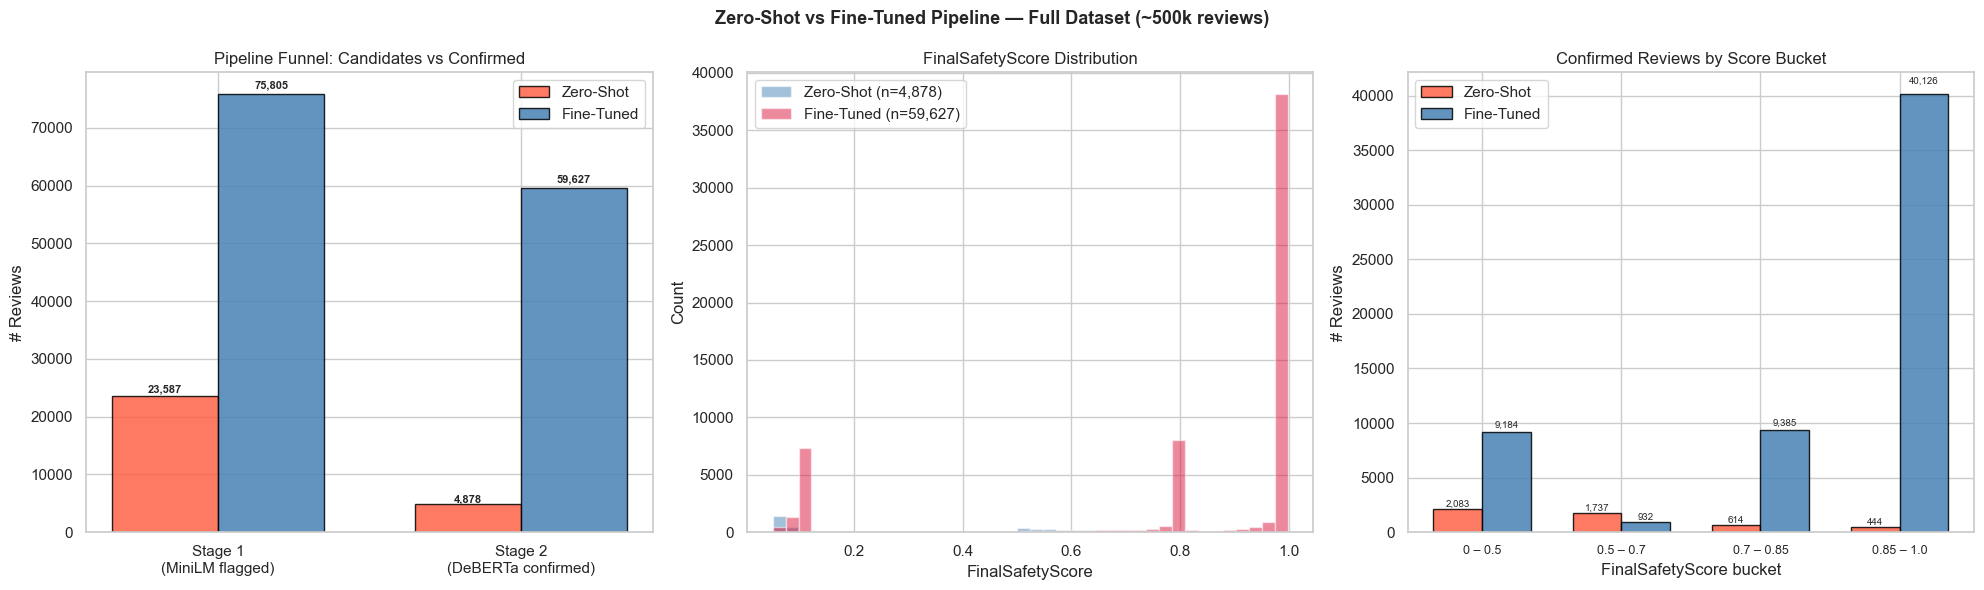

In [136]:
# ── 10.2  Visualisation — Zero-Shot vs Fine-Tuned ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Zero-Shot vs Fine-Tuned Pipeline — Full Dataset (~500k reviews)',
             fontsize=13, fontweight='bold')

width = 0.35
x2    = np.arange(2)

# ── Panel 1: Pipeline funnel — Stage 1 vs Stage 2 grouped bars ────────
counts_zs_bar = [_n_minilm,    _n_confirmed]
counts_ft_bar = [_n_minilm_ft, _n_confirmed_ft]

bars_zs1 = axes[0].bar(x2 - width / 2, counts_zs_bar, width,
                       label='Zero-Shot',  color='tomato',    edgecolor='black', alpha=0.85)
bars_ft1 = axes[0].bar(x2 + width / 2, counts_ft_bar, width,
                       label='Fine-Tuned', color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x2)
axes[0].set_xticklabels(['Stage 1\n(MiniLM flagged)', 'Stage 2\n(DeBERTa confirmed)'])
axes[0].set_title('Pipeline Funnel: Candidates vs Confirmed')
axes[0].set_ylabel('# Reviews')
axes[0].legend()
for bar in list(bars_zs1) + list(bars_ft1):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# ── Panel 2: FinalSafetyScore histogram overlay ────────────────────────
axes[1].hist(confirmed['FinalSafetyScore'],    bins=40, color='steelblue', alpha=0.5,
             label=f'Zero-Shot (n={len(confirmed):,})')
axes[1].hist(confirmed_ft['FinalSafetyScore'], bins=40, color='crimson',   alpha=0.5,
             label=f'Fine-Tuned (n={len(confirmed_ft):,})')
axes[1].set_title('FinalSafetyScore Distribution')
axes[1].set_xlabel('FinalSafetyScore')
axes[1].set_ylabel('Count')
axes[1].legend()

# ── Panel 3: Confirmed reviews per score bucket — grouped bar ──────────
_bucket_labels = ['0 – 0.5', '0.5 – 0.7', '0.7 – 0.85', '0.85 – 1.0']
_edges         = [0.0, 0.5, 0.7, 0.85, 1.01]

def _bucket_counts(scores):
    return [
        int(((scores >= lo) & (scores < hi)).sum())
        for lo, hi in zip(_edges[:-1], _edges[1:])
    ]

bkt_zs = _bucket_counts(confirmed['FinalSafetyScore'])
bkt_ft = _bucket_counts(confirmed_ft['FinalSafetyScore'])

x3       = np.arange(len(_bucket_labels))
bars_zs3 = axes[2].bar(x3 - width / 2, bkt_zs, width,
                       label='Zero-Shot',  color='tomato',    edgecolor='black', alpha=0.85)
bars_ft3 = axes[2].bar(x3 + width / 2, bkt_ft, width,
                       label='Fine-Tuned', color='steelblue', edgecolor='black', alpha=0.85)
axes[2].set_xticks(x3)
axes[2].set_xticklabels(_bucket_labels, fontsize=9)
axes[2].set_title('Confirmed Reviews by Score Bucket')
axes[2].set_xlabel('FinalSafetyScore bucket')
axes[2].set_ylabel('# Reviews')
axes[2].legend()
for bar in list(bars_zs3) + list(bars_ft3):
    h = bar.get_height()
    if h > 0:
        axes[2].text(bar.get_x() + bar.get_width() / 2, h * 1.02,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()